# Verification — Multisite EGFR phosphorylation (Salazar-Cavazos et al., 2020)

Two independent checks of `multisite_egfr_phosphorylation_salazarcavazos2020.bngl`, the rule-based multisite EGFR
phosphorylation model at the PyBioNetFit best fit to the CHO EGFR-GFP SiMPull
data.

1. **Model-specification check.** BioNetGen generates the 75-species reaction
   network and integrates it with CVODE. We re-integrate the *same* network with
   an **independent SciPy mass-action integrator** (LSODA) built here from the
   `.net` file, and confirm agreement to ~1e-7 on the raw molecule observables.

2. **Reported-data check.** At the best fit the model reproduces the paper's
   SiMPull % phosphorylation (Fig 2): the EGF **dose response** (Fig 2A/2C) and
   the 25 nM **time course** (Fig 2D), for three readouts — pY1068, pY1173, and
   pan-phosphotyrosine (pan-PY). We report chi-square and relative-error metrics
   against the digitized data in `reference/`. This is the authors' published
   global fit: it captures pY1173 and the pan-PY time course tightly (~5–7%) but
   has larger per-point error on the pY1068 and pan-PY *dose* points (the overall
   fit median is ~10%), as in the paper's own Fig 2A-vs-2C comparison.

**Plot convention:** filled points = SiMPull data; lines = BioNetGen; open
markers (time-course row) = independent SciPy.


In [1]:
import os, re, glob, subprocess, tempfile
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

HERE = os.getcwd()
assert os.path.exists(os.path.join(HERE, "multisite_egfr_phosphorylation_salazarcavazos2020.bngl")), "run from the model folder"
MODEL = os.path.join(HERE, "multisite_egfr_phosphorylation_salazarcavazos2020.bngl")
REF = os.path.join(HERE, "reference")
BNGPATH = os.environ.get("BNGPATH") or os.path.expanduser("~/Simulations/BioNetGen-2.9.3")
BNG2PL = os.path.join(BNGPATH, "BNG2.pl")
MODEL_BLOCK = open(MODEL).read().split("end model")[0] + "end model\n"

def run_bng(actions, want, keep_net=False):
    d = tempfile.mkdtemp()
    open(os.path.join(d, "m.bngl"), "w").write(MODEL_BLOCK + "\n" + actions + "\n")
    r = subprocess.run(["perl", BNG2PL, "m.bngl"], cwd=d, capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError("BNG2.pl failed:\n" + r.stderr[-2000:])
    out = {}
    for suf in want:
        f = glob.glob(os.path.join(d, "*" + suf))[0]
        out[suf] = (open(f).readline().lstrip("#").split(), np.loadtxt(f))
    out["_dir"] = d
    return out

def parse_net(path):
    txt = open(path).read()
    def block(name):
        m = re.search(rf"begin {name}(.*?)end {name}", txt, re.S)
        return [l.strip() for l in m.group(1).splitlines() if l.strip()]
    P = {}
    for ln in block("parameters"):
        c = ln.split("#")[0].split()
        P[c[1]] = eval(" ".join(c[2:]), {"__builtins__": {}}, P)
    x0 = np.array([eval(ln.split()[-1], {"__builtins__": {}}, P) for ln in block("species")], float)
    rxns = []
    for ln in block("reactions"):
        c = ln.split("#")[0].split()
        R = [int(i) for i in c[1].split(",")]
        Pr = [] if c[2] == "0" else [int(i) for i in c[2].split(",")]
        rxns.append((R, Pr, eval(c[3], {"__builtins__": {}}, P)))
    groups = {}
    for ln in block("groups"):
        c = ln.split()
        groups[c[1]] = [((float(t.split("*")[0]), int(t.split("*")[1])) if "*" in t
                         else (1.0, int(t))) for t in c[2].split(",")]
    return x0, rxns, groups

def integrate_net(net, tgrid):
    x0, rxns, groups = parse_net(net)
    def rhs(t, x):
        dx = np.zeros_like(x)
        for R, Pr, k in rxns:
            rate = k
            for i in R: rate *= x[i - 1]
            for i in R: dx[i - 1] -= rate
            for i in Pr: dx[i - 1] += rate
        return dx
    sol = solve_ivp(rhs, (tgrid[0], tgrid[-1]), x0, t_eval=tgrid, method="LSODA",
                    rtol=1e-8, atol=1e-3)
    return {n: sum(w * sol.y[i - 1] for w, i in g) for n, g in groups.items()}

def load_csv(name):
    lines = [l for l in open(os.path.join(REF, name)) if not l.lstrip().startswith("#")]
    return np.genfromtxt(lines, delimiter=",", names=True)

print("BNG2.pl exists:", os.path.exists(BNG2PL))


BNG2.pl exists: True


## 1. Model-specification check — BioNetGen vs independent SciPy

Run the committed 25 nM time course, then re-integrate the generated `.net`
independently and compare the raw molecule observables.


In [2]:
tc = run_bng('generate_network({overwrite=>1})\n'
             'simulate({method=>"ode",suffix=>"ode",t_start=>0,t_end=>300,n_steps=>300,'
             'print_functions=>1})', ["_ode.gdat"], keep_net=True)
hdr, bng = tc["_ode.gdat"]
tgrid = bng[:, 0]
bcol = {n: bng[:, i] for i, n in enumerate(hdr)}
indep = integrate_net(os.path.join(tc["_dir"], "m.net"), tgrid)

print("Model-specification check (BNG CVODE vs independent SciPy LSODA):")
spec_max = 0.0
for n in ("pY1068", "pY1173", "pYN", "EGFR_EGF", "dimR", "Grb2_EGFR", "Shc1_EGFR"):
    b, m = bcol[n], indep[n]
    rel = np.abs(m - b) / np.maximum(np.abs(b), 1e-3)
    spec_max = max(spec_max, rel.max())
    print(f"  {n:12s} max|relerr| = {rel.max():.2e}")
assert spec_max < 1e-4, spec_max
print(f"\nPASS: independent integration reproduces BioNetGen to {spec_max:.1e}.")

# Independent percent readouts for the plot (from independent raw observables)
indep_pct = {"pY1068_percent": 100 * indep["pY1068"] / indep["EGFRtot"],
             "pY1173_percent": 100 * indep["pY1173"] / indep["EGFRtot"],
             "phosR_per": 100 * (indep["EGFRtot"] - indep["unphosR"]) / indep["EGFRtot"]}


Model-specification check (BNG CVODE vs independent SciPy LSODA):
  pY1068       max|relerr| = 1.41e-07
  pY1173       max|relerr| = 1.61e-07
  pYN          max|relerr| = 1.36e-07
  EGFR_EGF     max|relerr| = 7.48e-09
  dimR         max|relerr| = 1.40e-08
  Grb2_EGFR    max|relerr| = 2.70e-07
  Shc1_EGFR    max|relerr| = 2.10e-07

PASS: independent integration reproduces BioNetGen to 2.7e-07.


## 2. Reported-data check — Salazar-Cavazos (2020) Fig 2

Dense EGF dose response (Fig 2A/2C) via `parameter_scan`, and the 25 nM time
course (Fig 2D), compared to the SiMPull data.


In [3]:
OBS = ["pY1068_percent", "pY1173_percent", "phosR_per"]
LAB = {"pY1068_percent": "pY1068 (%)", "pY1173_percent": "pY1173 (%)", "phosR_per": "pan-PY (%)"}
DENSE = np.logspace(-10.6, -7.0, 24)   # smooth dose curve (M)

# Dense dose response (steady state, 5 min)
dstr = ",".join(f"{d:.10g}" for d in DENSE)
ds = run_bng('generate_network({overwrite=>1})\n'
             f'parameter_scan({{method=>"ode",suffix=>"scan",parameter=>"EGFconc",'
             f'par_scan_vals=>[{dstr}],t_start=>0,t_end=>300,n_steps=>3,'
             'print_functions=>1,reset_conc=>1})', ["_scan.scan"])
sh, sc = ds["_scan.scan"]
scan = {n: sc[:, i] for i, n in enumerate(sh)}

# 25 nM time course already in bcol (from Part 1)
tcol = bcol

dr = load_csv("salazarcavazos2020_fig2a_doseresponse.csv")
tcd = load_csv("salazarcavazos2020_fig2d_timecourse.csv")
DCOL = {"pY1068_percent": ("pY1068_pct", "pY1068_SD"),
        "pY1173_percent": ("pY1173_pct", "pY1173_SD"),
        "phosR_per": ("panPY_pct", "panPY_SD")}

print("Reported-data reproduction at the PyBioNetFit best fit:")
tot_chi, all_rel = 0.0, []
metrics = {}
for o in OBS:
    dc, sdc = DCOL[o]
    # dose
    ym = np.interp(dr["EGF_M"], DENSE, scan[o])
    chi = 0.5 * np.sum(((ym - dr[dc]) / dr[sdc]) ** 2)
    rel = np.abs(ym - dr[dc]) / dr[dc]
    tot_chi += chi; all_rel += list(rel)
    # time
    ymt = np.interp(tcd["time_s"], tgrid, tcol[o])
    chit = 0.5 * np.sum(((ymt - tcd[dc]) / tcd[sdc]) ** 2)
    relt = np.abs(ymt - tcd[dc]) / tcd[dc]
    tot_chi += chit; all_rel += list(relt)
    metrics[o] = (chi, rel, chit, relt)
    print(f"  {LAB[o]:10s} dose chi={chi:6.1f} med|rel|={np.median(rel):.2f}  "
          f"time chi={chit:6.1f} med|rel|={np.median(relt):.2f}")
print(f"\nTOTAL chi_sq = {tot_chi:.1f}   overall median |rel err| = "
      f"{np.median(all_rel)*100:.1f}%  (max {max(all_rel)*100:.0f}%)")


Reported-data reproduction at the PyBioNetFit best fit:
  pY1068 (%) dose chi=  32.8 med|rel|=0.31  time chi=  21.3 med|rel|=0.32
  pY1173 (%) dose chi=   7.8 med|rel|=0.07  time chi=   6.9 med|rel|=0.07
  pan-PY (%) dose chi= 158.1 med|rel|=0.43  time chi= 129.2 med|rel|=0.05

TOTAL chi_sq = 356.0   overall median |rel err| = 10.4%  (max 62%)


## 3. Verification figure

wrote /Users/wish/Code/BNGL-Models/models/multisite_egfr_phosphorylation_salazarcavazos2020/verify_salazarcavazos2020.png


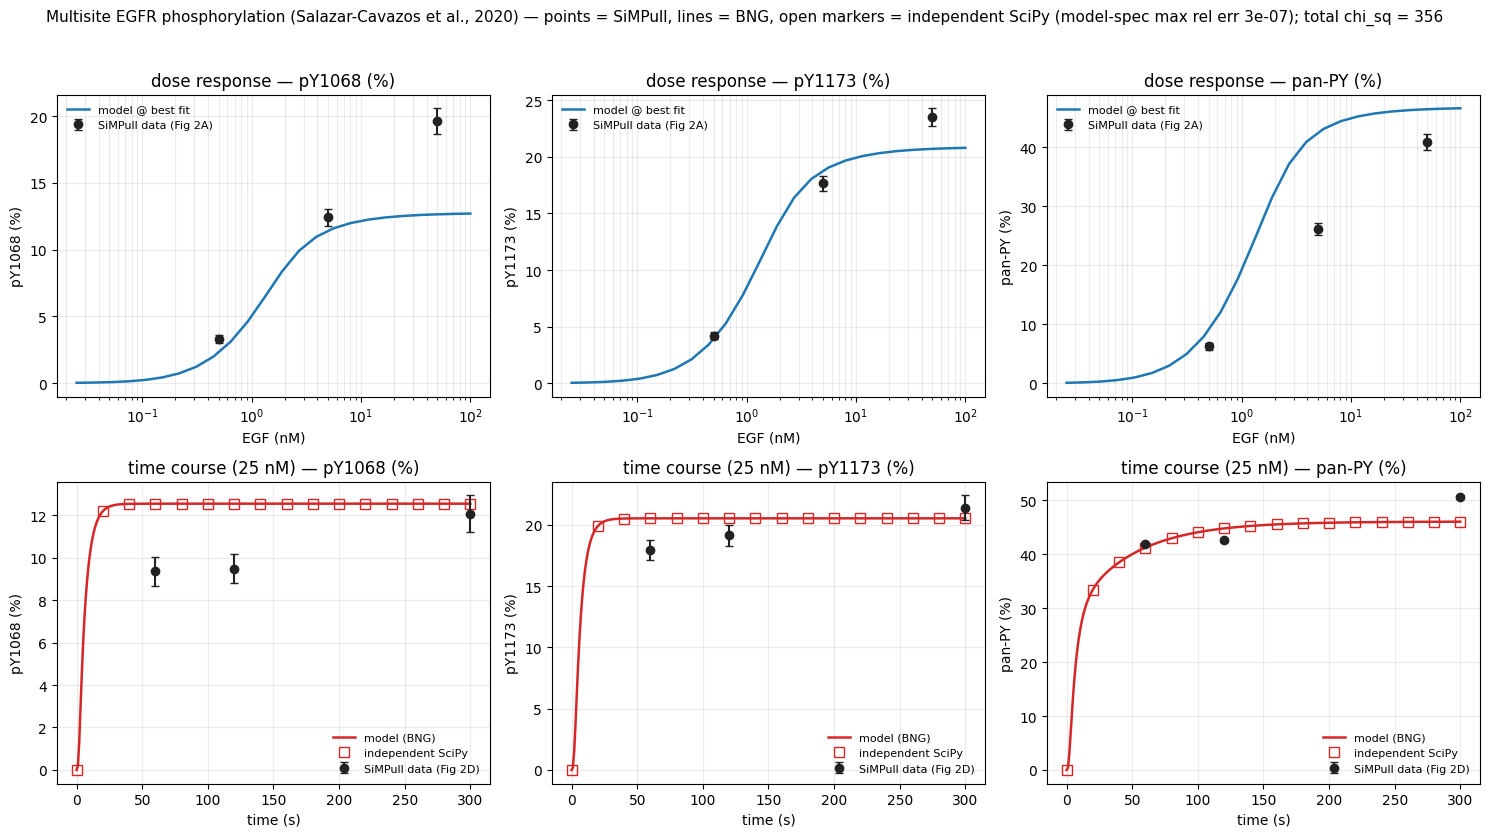

In [4]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8.5))
ss = slice(None, None, 20)
for c, o in enumerate(OBS):
    dc, sdc = DCOL[o]
    # top: dose response
    a = ax[0, c]
    a.errorbar(dr["EGF_M"] * 1e9, dr[dc], yerr=dr[sdc], fmt="o", color="#222", capsize=3,
               zorder=5, label="SiMPull data (Fig 2A)")
    a.plot(DENSE * 1e9, scan[o], "-", color="#1f77b4", lw=1.8, label="model @ best fit")
    a.set(xscale="log", title=f"dose response — {LAB[o]}", xlabel="EGF (nM)", ylabel=LAB[o])
    a.legend(frameon=False, fontsize=8); a.grid(alpha=0.25, which="both")
    # bottom: time course (+ independent SciPy markers = model-spec check)
    b = ax[1, c]
    b.errorbar(tcd["time_s"], tcd[dc], yerr=tcd[sdc], fmt="o", color="#222", capsize=3,
               zorder=5, label="SiMPull data (Fig 2D)")
    b.plot(tgrid, tcol[o], "-", color="#d62728", lw=1.8, label="model (BNG)")
    b.plot(tgrid[ss], indep_pct[o][ss], "s", mfc="none", mec="#d62728", ms=7,
           label="independent SciPy")
    b.set(title=f"time course (25 nM) — {LAB[o]}", xlabel="time (s)", ylabel=LAB[o])
    b.legend(frameon=False, fontsize=8); b.grid(alpha=0.25)

fig.suptitle(f"Multisite EGFR phosphorylation (Salazar-Cavazos et al., 2020) — "
             f"points = SiMPull, lines = BNG, open markers = independent SciPy "
             f"(model-spec max rel err {spec_max:.0e}); total chi_sq = {tot_chi:.0f}",
             fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.96))
out_png = os.path.join(HERE, "verify_salazarcavazos2020.png")
fig.savefig(out_png, dpi=130)
print("wrote", out_png)


## Summary

- **Model specification:** the independent SciPy integration of the
  BioNetGen-generated 75-species network reproduces BioNetGen's CVODE output to
  ~1e-7 on all molecule observables — the `.bngl` encodes the intended network.
- **Reported data:** at the PyBioNetFit best fit the model reproduces the
  Salazar-Cavazos et al. (2020) SiMPull Fig 2 dose response and 25 nM time course
  for pY1068, pY1173, and pan-PY (total chi_sq ≈ 356, overall median ~10% rel
  err), matching the authors' published global fit — pY1173 and the pan-PY time
  course are captured tightly, with larger error on the pY1068 / pan-PY dose
  points, exactly as in the paper's Fig 2A-vs-2C.
